# Visualizations

## IPL Capstone Project

<b>The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.</b>

<b>These are some of the important columns that we'll focus on for meaningful insights in this project.</b>

column names: Variable Type

date : string

venue : string

stage : string

team1 : string

team2 : string

toss_winner : string

toss_decision : string

first_ings_score : integer

second_ings_score : integer

match_winner : string

won_by : string

margin : integer

player_of_the_match : string

top_scorer : string

highscore : integer

best_bowling : string

best_bowling_fgure : string

gure : string

<b>The workflow is that all the tasks and implementations are given individually.</b>

#### Loading the Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv("files & images/ipl.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


#### Basic Information

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

##### Which columns have null values

In [3]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

#### Basic Questions

##### 1. Which team won the most matches ?

Text(0.5, 1.0, 'Most match wins by teams')

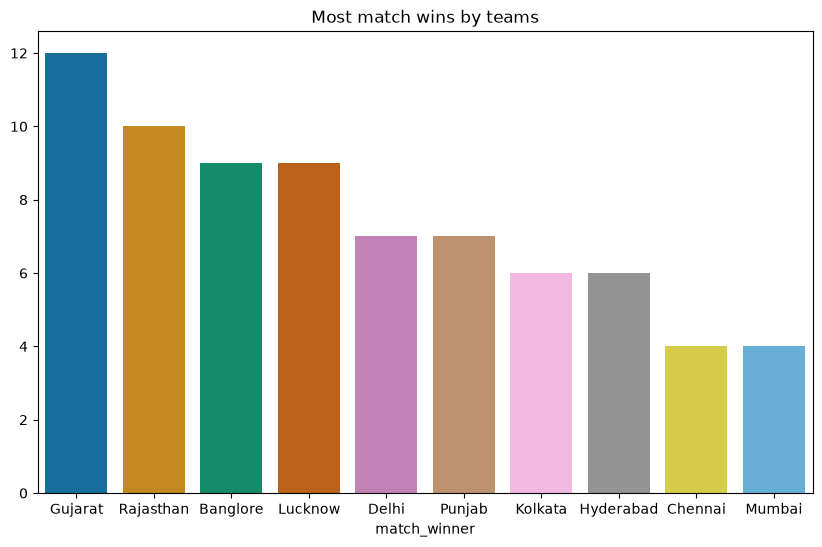

In [4]:
match_wins = df['match_winner'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=match_wins.index, y=match_wins.values, palette='colorblind')
plt.title("Most match wins by teams")

##### 2. Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

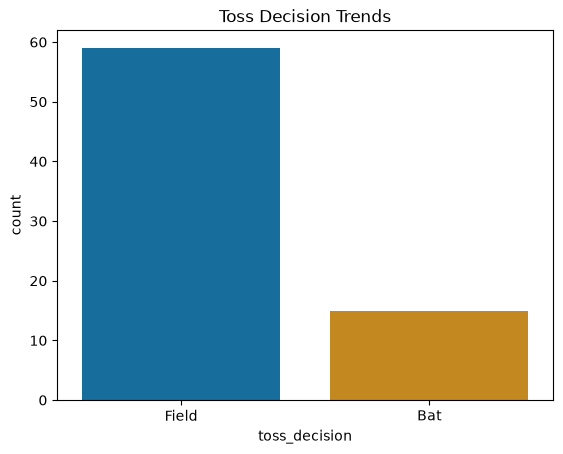

In [5]:
sns.countplot(x=df['toss_decision'], palette='colorblind')
plt.title('Toss Decision Trends')

##### 3. Toss Winner vs Match Winner

In [6]:
prob_tosswin_matchwin = (df['toss_winner'] == df['match_winner']).mean() * 100
prob_tosswin_matchwin.round(2)

np.float64(48.65)

##### 4. How do teams win ? (Runs vs Wickets)

Text(0.5, 1.0, 'Teams won by Runs or Wickets ?')

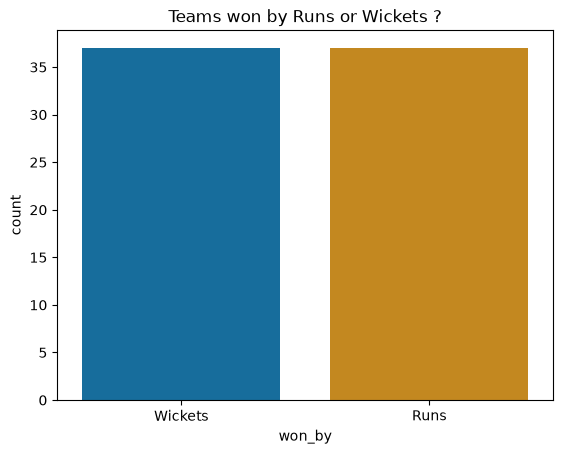

In [7]:
sns.countplot(x=df['won_by'], palette='colorblind')
plt.title('Teams won by Runs or Wickets ?')

#### Key Players Performence

##### 1. Top 10 most "Player of the Match" Awards

Text(0.5, 1.0, 'Top 10 Player of the Match')

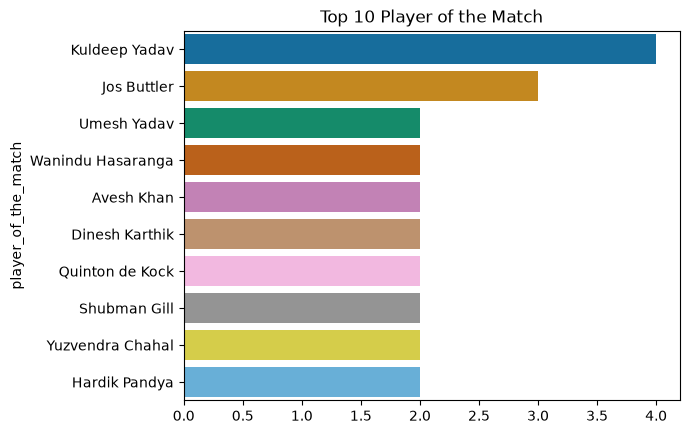

In [8]:
top_10_player_of_the_match = df['player_of_the_match'].value_counts().head(10)

sns.barplot(x=top_10_player_of_the_match.values, y=top_10_player_of_the_match.index, palette='colorblind')
plt.title('Top 10 Player of the Match')

##### 2. Top 2 scorers

Text(0.5, 1.0, 'Top 2 Scorers')

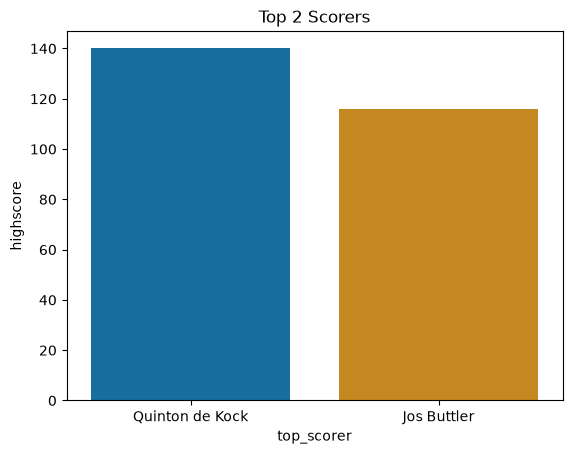

In [9]:
top_2_scorers = df.sort_values(by='highscore', ascending=False).head(2)[['top_scorer', 'highscore']]

sns.barplot(x=top_2_scorers['top_scorer'], y=top_2_scorers['highscore'], palette='colorblind')
plt.title('Top 2 Scorers')

##### 3. Top 10 Balling Figures

In [10]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0]).astype(int)
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


Text(0.5, 1.0, 'Top 10 Ballers')

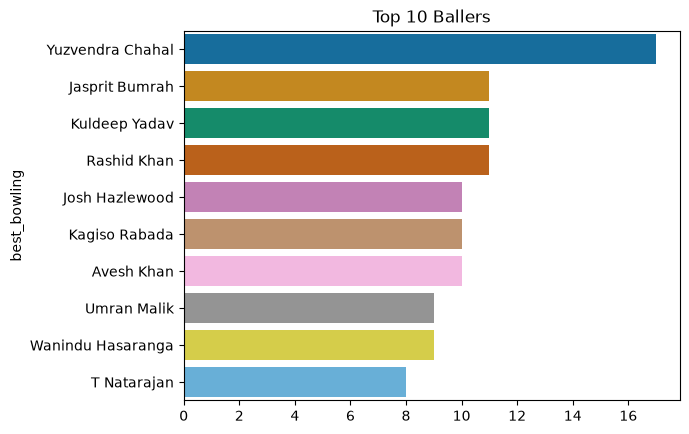

In [11]:
top_10_ballers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_10_ballers.values, y=top_10_ballers.index, palette='colorblind')
plt.title('Top 10 Ballers')

#### Venue Analysis

##### Most matches played by venue

Text(0.5, 1.0, 'Most Matched Played by Venue')

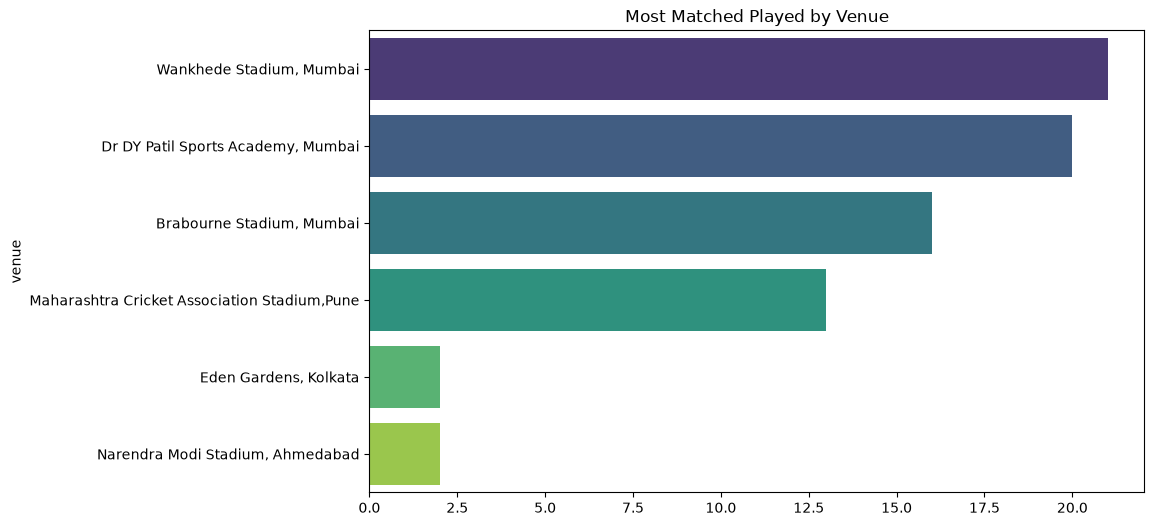

In [12]:
most_matches_venue = df['venue'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=most_matches_venue.values, y=most_matches_venue.index, palette='viridis')
plt.title('Most Matched Played by Venue')

#### Custom Questions & Insights

##### 1. Who won the highest margin by runs ?

In [21]:
highest_margin_idx = [df[df['won_by'] == 'Runs']['margin'].idxmax()]
df.loc[highest_margin_idx, ['match_id', 'match_winner', 'won_by', 'margin']]

,match_id,match_winner,won_by,margin
54,55,Chennai,Runs,91


##### 2. Which player had the highest individual score ?

In [34]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


##### 3. Which bowler had the best bowling figures ?

In [39]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
